# 04 — Revenue Trend Analysis

**Goal:** Understand *when* revenue is earned (seasonality, growth over time), *what* drives it (top products), and *where* it comes from (countries). This uses `cleaned_full_revenue.csv`, which — unlike the customer-level dataset — includes guest/unidentified checkouts, since we don't need a `CustomerID` for revenue totals to be valid.

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\ProProjects\data-analytics-projects\ecom\outputs\data\cleaned_full_revenue.csv", parse_dates=['invoicedate'])
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")
df.head()

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,iscancellation,totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


## 1. Overall Monthly Revenue Trend

Note: December 2011 is a partial month because the dataset ends early in December. Any apparent decline in revenue for this month should therefore be interpreted with caution.

Number of distinct days with transactions in the final month (2011-12): 8


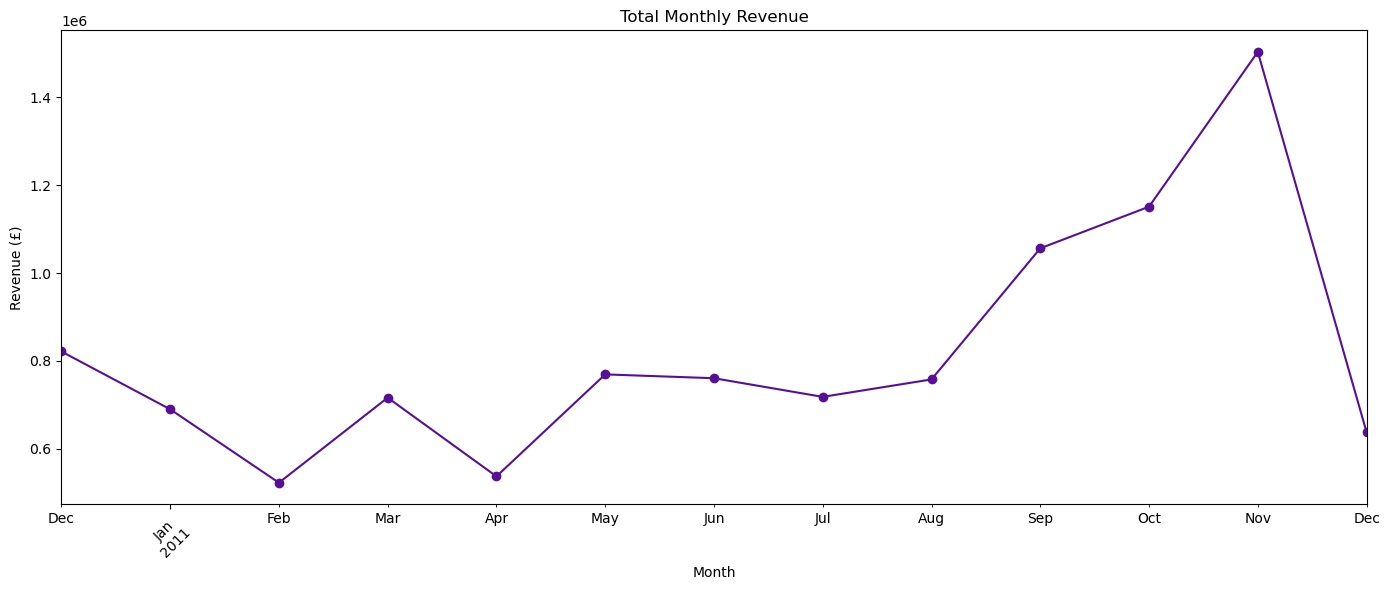

In [4]:
df['yearmonth'] = df['invoicedate'].dt.to_period('M')
monthly_revenue = df.groupby('yearmonth')['totalprice'].sum()

# Flag whether the last month is a partial month (fewer distinct days than a typical month)
last_month_days = df[df['yearmonth'] == monthly_revenue.index.max()]['invoicedate'].dt.day.nunique()
print(f"Number of distinct days with transactions in the final month ({monthly_revenue.index.max()}): {last_month_days}")

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o', color='#571095')
plt.title('Total Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', bbox_inches='tight')
plt.show()